In [1]:
import numpy as np
import pandas as pd
from nuscenes.nuscenes import NuScenes

np.random.seed(42)  # 固定随机种子，保证结果可复现——case study 必需

nusc = NuScenes(version='v1.0-mini',
                dataroot='/Users/louise/projects/nuScenes_IAA/data',
                verbose=False)

# 把所有 sample_annotation 拍平成一张 DataFrame
records = []
for ann in nusc.sample_annotation:
    records.append({
        'ann_token':     ann['token'],
        'sample_token':  ann['sample_token'],
        'instance_token': ann['instance_token'],
        'category':      ann['category_name'],
        'x': ann['translation'][0],
        'y': ann['translation'][1],
        'z': ann['translation'][2],
        'w': ann['size'][0],
        'l': ann['size'][1],
        'h': ann['size'][2],
        'yaw_qw': ann['rotation'][0],   # 四元数，后面转成角度
        'yaw_qx': ann['rotation'][1],
        'yaw_qy': ann['rotation'][2],
        'yaw_qz': ann['rotation'][3],
        'num_lidar_pts': ann['num_lidar_pts'],
    })

df = pd.DataFrame(records)
print(f"总标注数: {len(df)}")
print(f"\n类别分布:\n{df['category'].value_counts()}")

总标注数: 18538

类别分布:
category
vehicle.car                             7619
human.pedestrian.adult                  4765
movable_object.barrier                  2323
movable_object.trafficcone              1378
vehicle.truck                            649
vehicle.motorcycle                       471
vehicle.bus.rigid                        353
vehicle.bicycle                          243
vehicle.construction                     196
human.pedestrian.construction_worker     193
movable_object.pushable_pullable          82
vehicle.trailer                           60
vehicle.bus.bendy                         57
static_object.bicycle_rack                54
human.pedestrian.child                    46
human.pedestrian.personal_mobility        25
movable_object.debris                     13
human.pedestrian.police_officer           11
Name: count, dtype: int64


In [6]:
# ============================================
# Cell 2: 生成"标注员 2" —— 受控高斯扰动
# ============================================

# 可调参数（第一轮初值，待 IoU 校准后确定终值）
SIGMA_POS = 0.12      # 位置噪声 σ，单位米
SIGMA_SIZE = 0.05     # 尺寸乘性噪声 σ（5%）
SIGMA_YAW_DEG = 5.0   # 朝向噪声 σ，单位度
P_CAT_CONFUSION = 0.05  # 类别混淆概率

# 易混类别映射（只在语义相近的类别间混淆，模拟真实标注员的错法）
CONFUSION_MAP = {
    'human.pedestrian.adult': ['human.pedestrian.construction_worker'],
    'human.pedestrian.construction_worker': ['human.pedestrian.adult'],
    'human.pedestrian.child': ['human.pedestrian.adult'],
    'vehicle.car': ['vehicle.truck'],
    'vehicle.truck': ['vehicle.car', 'vehicle.construction'],
    'vehicle.bus.rigid': ['vehicle.bus.bendy', 'vehicle.truck'],
    'vehicle.bus.bendy': ['vehicle.bus.rigid'],
    'vehicle.bicycle': ['vehicle.motorcycle'],
    'vehicle.motorcycle': ['vehicle.bicycle'],
    'movable_object.barrier': ['movable_object.trafficcone'],
    'movable_object.trafficcone': ['movable_object.barrier'],
}

def perturb_annotations(df, sigma_pos, sigma_size, sigma_yaw_deg, p_confusion):
    """基于标注员1(ground truth)生成模拟的标注员2"""
    df2 = df.copy()
    n = len(df2)

    # 位置：加性高斯噪声（x, y 各自独立扰动；z 对 BEV IoU 无影响，也扰动保持真实感）
    df2['x'] += np.random.normal(0, sigma_pos, n)
    df2['y'] += np.random.normal(0, sigma_pos, n)
    df2['z'] += np.random.normal(0, sigma_pos * 0.5, n)  # 垂直方向人手误差通常更小

    # 尺寸：乘性高斯噪声
    df2['w'] *= np.random.normal(1, sigma_size, n).clip(0.8, 1.2)
    df2['l'] *= np.random.normal(1, sigma_size, n).clip(0.8, 1.2)
    df2['h'] *= np.random.normal(1, sigma_size, n).clip(0.8, 1.2)

    # 朝向：先从四元数取出 yaw 角，加噪声（简化处理，nuScenes 的框旋转主要在 yaw）
    yaw = 2 * np.arctan2(df2['yaw_qz'], df2['yaw_qw'])   # 四元数 → yaw 弧度
    yaw += np.random.normal(0, np.deg2rad(sigma_yaw_deg), n)
    df2['yaw'] = yaw

    # 类别：低概率混淆
    def confuse(cat):
        if cat in CONFUSION_MAP and np.random.rand() < p_confusion:
            return np.random.choice(CONFUSION_MAP[cat])
        return cat
    df2['category'] = df2['category'].apply(confuse)

    return df2

# 标注员1也需要 yaw 列（用于 IoU 计算）
df['yaw'] = 2 * np.arctan2(df['yaw_qz'], df['yaw_qw'])

df_annotator2 = perturb_annotations(df, SIGMA_POS, SIGMA_SIZE, SIGMA_YAW_DEG, P_CAT_CONFUSION)

# 快速验收
diff_pos = np.sqrt((df_annotator2['x'] - df['x'])**2 + (df_annotator2['y'] - df['y'])**2)
cat_changed = (df_annotator2['category'] != df['category']).mean()
print(f"位置偏移: 中位数 {diff_pos.median():.3f}m, 95分位 {diff_pos.quantile(0.95):.3f}m")
print(f"类别被混淆的比例: {cat_changed:.1%}")

位置偏移: 中位数 0.140m, 95分位 0.291m
类别被混淆的比例: 4.8%


In [7]:
!pip install shapely


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [8]:
from shapely.geometry import Polygon
print("shapely OK")

shapely OK


In [9]:
# ============================================
# Cell 3: BEV IoU —— 两个旋转矩形的重叠度
# ============================================
from shapely.geometry import Polygon

def bev_polygon(x, y, w, l, yaw):
    """把一个 3D 框投影成俯视图上的旋转矩形 (shapely Polygon)"""
    # 未旋转时四个角相对中心的坐标 (l 沿朝向, w 垂直朝向)
    corners = np.array([
        [ l/2,  w/2],
        [ l/2, -w/2],
        [-l/2, -w/2],
        [-l/2,  w/2],
    ])
    # 旋转矩阵
    rot = np.array([
        [np.cos(yaw), -np.sin(yaw)],
        [np.sin(yaw),  np.cos(yaw)],
    ])
    corners = corners @ rot.T + np.array([x, y])
    return Polygon(corners)

def bev_iou(row1, row2):
    """两条标注记录的 BEV IoU"""
    p1 = bev_polygon(row1['x'], row1['y'], row1['w'], row1['l'], row1['yaw'])
    p2 = bev_polygon(row2['x'], row2['y'], row2['w'], row2['l'], row2['yaw'])
    if not p1.is_valid or not p2.is_valid:
        return 0.0
    inter = p1.intersection(p2).area
    union = p1.union(p2).area
    return inter / union if union > 0 else 0.0

# 对全部 18538 对标注计算 IoU(两位"标注员"的行是一一对应的,直接按行配对)
ious = np.array([
    bev_iou(df.iloc[i], df_annotator2.iloc[i])
    for i in range(len(df))
])
df['iou'] = ious
df['cat_annotator2'] = df_annotator2['category'].values

# ===== 校准检查 =====
print(f"IoU 中位数:   {np.median(ious):.3f}")
print(f"IoU 均值:     {ious.mean():.3f}")
print(f"IoU 25分位:   {np.percentile(ious, 25):.3f}")
print(f"IoU 75分位:   {np.percentile(ious, 75):.3f}")
print(f"IoU < 0.5 占比: {(ious < 0.5).mean():.1%}")

IoU 中位数:   0.768
IoU 均值:     0.709
IoU 25分位:   0.610
IoU 75分位:   0.840
IoU < 0.5 占比: 14.6%


In [10]:
# ============================================
# Cell 4: Cohen's Kappa —— 类别标注一致性
# ============================================
from sklearn.metrics import cohen_kappa_score

# 全体 Kappa:标注员1 vs 标注员2 的类别判定
kappa_overall = cohen_kappa_score(df['category'], df['cat_annotator2'])

# 原始一致率(用来做对比,展示 Kappa 的价值)
raw_agreement = (df['category'] == df['cat_annotator2']).mean()

print(f"原始一致率:     {raw_agreement:.3f}")
print(f"Cohen's Kappa: {kappa_overall:.3f}")
print(f"差值(运气成分): {raw_agreement - kappa_overall:.3f}")

原始一致率:     0.952
Cohen's Kappa: 0.936
差值(运气成分): 0.016


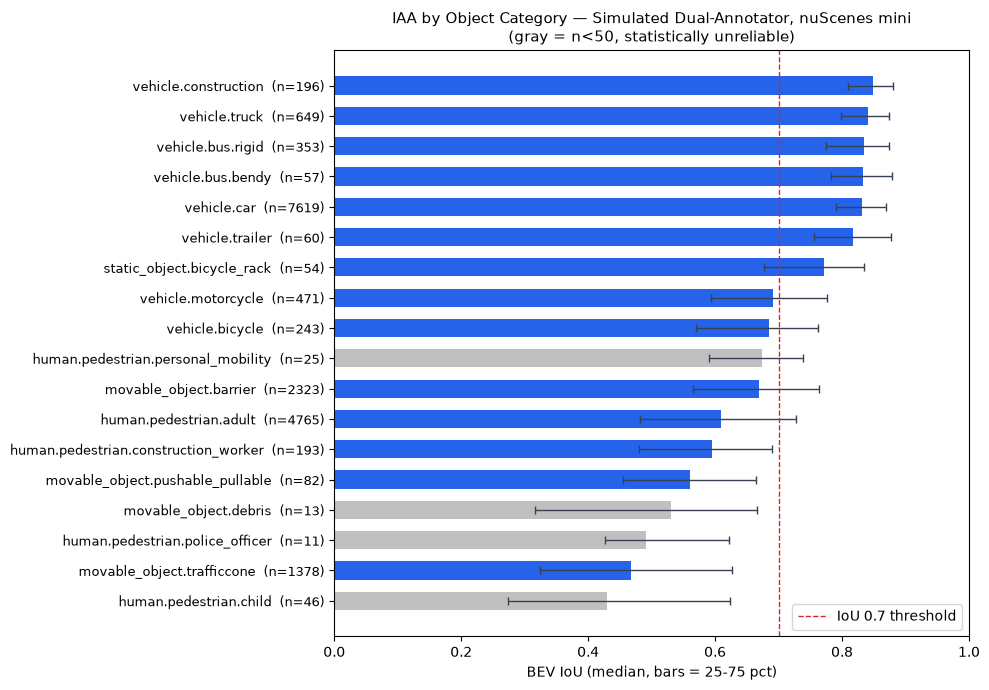


物体平均宽度 vs IoU中位数 相关系数: 0.844
(预期为正——物体越大,同样手误下 IoU 越高)


In [17]:
# ============================================
# Cell 5: 按类别的 IAA 分布 —— Step 2 核心产出图
# ============================================
import matplotlib.pyplot as plt

MIN_SAMPLES = 50  # 样本量阈值,低于此灰显

stats = df.groupby('category').agg(
    iou_median=('iou', 'median'),
    iou_p25=('iou', lambda s: s.quantile(0.25)),
    iou_p75=('iou', lambda s: s.quantile(0.75)),
    count=('iou', 'size'),
    avg_width=('w', 'mean'),   # 用平均宽度验证"尺寸梯度"假设
).sort_values('iou_median')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0c0c0' if c < MIN_SAMPLES else '#2563eb' for c in stats['count']]
y = np.arange(len(stats))

# 横向柱 + 25-75 分位误差线
ax.barh(y, stats['iou_median'], color=colors, height=0.6)
ax.errorbar(stats['iou_median'], y,
            xerr=[stats['iou_median'] - stats['iou_p25'],
                  stats['iou_p75'] - stats['iou_median']],
            fmt='none', ecolor='#374151', capsize=3, linewidth=1)

# 类别名 + 样本量标注
ax.set_yticks(y)
ax.set_yticklabels([f"{cat}  (n={int(c)})"
                    for cat, c in zip(stats.index, stats['count'])], fontsize=9)
ax.axvline(0.7, color='#dc2626', linestyle='--', linewidth=1, label='IoU 0.7 threshold')
ax.set_xlabel('BEV IoU (median, bars = 25-75 pct)')
ax.set_title('IAA by Object Category — Simulated Dual-Annotator, nuScenes mini\n'
             f'(gray = n<{MIN_SAMPLES}, statistically unreliable)', fontsize=11)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('iaa_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# 验证尺寸梯度假设:宽度 vs IoU 的相关性
reliable = stats[stats['count'] >= MIN_SAMPLES]
corr = reliable['avg_width'].corr(reliable['iou_median'])
print(f"\n物体平均宽度 vs IoU中位数 相关系数: {corr:.3f}")
print(f"(预期为正——物体越大,同样手误下 IoU 越高)")

In [12]:
# ============================================
# Cell 6 (Step 3): 把 scene 维度信息 join 进标注表
# ============================================

# 建立 sample_token → scene 信息的映射
sample_to_scene = {}
for scene in nusc.scene:
    desc = scene['description'].lower()
    # 从 description 提取环境标签(nuScenes 没有结构化天气字段,用描述关键词)
    is_night = 'night' in desc
    is_rain = 'rain' in desc
    tok = scene['first_sample_token']
    while tok != '':
        s = nusc.get('sample', tok)
        sample_to_scene[tok] = {
            'scene_name': scene['name'],
            'is_night': is_night,
            'is_rain': is_rain,
        }
        tok = s['next']

df['scene_name'] = df['sample_token'].map(lambda t: sample_to_scene[t]['scene_name'])
df['is_night']   = df['sample_token'].map(lambda t: sample_to_scene[t]['is_night'])

print(df.groupby('is_night')['iou'].agg(['median', 'mean', 'count']))

            median      mean  count
is_night                           
False     0.768003  0.708020  14897
True      0.770557  0.713038   3641


In [15]:
# ============================================
# Cell 7 (Step 3): 环境感知扰动 —— σ 按场景条件缩放
# ============================================
NIGHT_MULTIPLIER = 1.5   # 假设值:夜间误差放大 50%(待真实数据校准)
RAIN_MULTIPLIER = 1.3    # 假设值:雨天再放大 30%

# 补上 is_rain 列(Cell 6 只 map 了 is_night)
df['is_rain'] = df['sample_token'].map(lambda t: sample_to_scene[t]['is_rain'])

# 每条标注自己的 σ:基础值 × 环境系数
sigma_per_row = np.full(len(df), 0.12)
sigma_per_row *= np.where(df['is_night'], NIGHT_MULTIPLIER, 1.0)
sigma_per_row *= np.where(df['is_rain'],  RAIN_MULTIPLIER, 1.0)

# 用逐行 σ 重新生成"标注员2"(只重扰动位置——环境主要影响定位精度)
np.random.seed(42)
df_a2_env = df.copy()
n = len(df)
df_a2_env['x'] = df['x'] + np.random.normal(0, 1, n) * sigma_per_row
df_a2_env['y'] = df['y'] + np.random.normal(0, 1, n) * sigma_per_row
df_a2_env['z'] = df['z'] + np.random.normal(0, 1, n) * sigma_per_row * 0.5
df_a2_env['w'] = df['w'] * np.random.normal(1, 0.05, n).clip(0.8, 1.2)
df_a2_env['l'] = df['l'] * np.random.normal(1, 0.05, n).clip(0.8, 1.2)
df_a2_env['h'] = df['h'] * np.random.normal(1, 0.05, n).clip(0.8, 1.2)
df_a2_env['yaw'] = df['yaw'] + np.random.normal(0, np.deg2rad(5), n)

# 重算 IoU
ious_env = np.array([
    bev_iou(df.iloc[i], df_a2_env.iloc[i]) for i in range(n)
])
df['iou_env'] = ious_env

# 分环境对比
print("=== 环境感知模拟下的 IoU ===")
print(df.groupby('is_night')['iou_env'].agg(['median', 'mean', 'count']))
print()
# 夜间 × 类别的交叉:找"双重打击"区
night_cat = df[df['is_night']].groupby('category')['iou_env'].agg(['median','count'])
day_cat   = df[~df['is_night']].groupby('category')['iou_env'].agg(['median','count'])
compare = day_cat.join(night_cat, lsuffix='_day', rsuffix='_night')
compare['iou_drop'] = compare['median_day'] - compare['median_night']
print(compare.sort_values('iou_drop', ascending=False).head(8).round(3))
print(df.groupby('is_rain')['iou_env'].agg(['median', 'mean', 'count']))
print(df.groupby(['is_night','is_rain'])['iou_env'].agg(['median','count']))

=== 环境感知模拟下的 IoU ===
            median      mean  count
is_night                           
False     0.766233  0.706710  14897
True      0.676326  0.593837   3641

                        median_day  count_day  median_night  count_night  \
category                                                                   
human.pedestrian.adult       0.607       3326         0.374       1439.0   
vehicle.bicycle              0.686        170         0.472         73.0   
vehicle.motorcycle           0.702        337         0.525        134.0   
movable_object.barrier       0.674       2178         0.505        145.0   
vehicle.car                  0.832       5957         0.786       1662.0   
vehicle.bus.rigid            0.836        201         0.804        152.0   
vehicle.construction         0.852        185         0.839         11.0   
human.pedestrian.child       0.485         46           NaN          NaN   

                        iou_drop  
category                          
hum

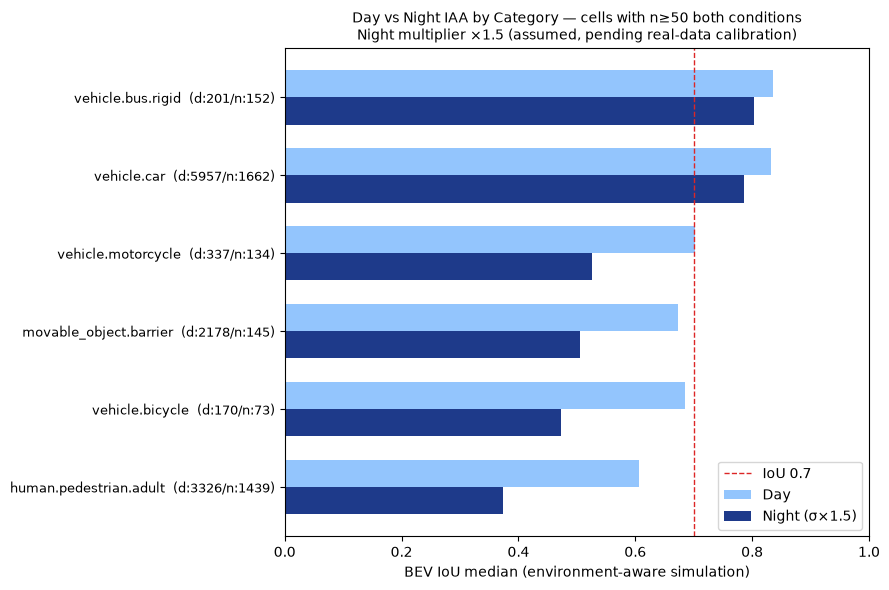

In [16]:
# ============================================
# Cell 8 (Step 3 收尾): 夜昼 × 类别 分组对比图
# ============================================
MIN_N = 50  # 每格最低样本量,低于则不画(护栏原则的图上执行)

grp = df.groupby(['category', 'is_night'])['iou_env'].agg(['median', 'count']).reset_index()
piv_med = grp.pivot(index='category', columns='is_night', values='median')
piv_cnt = grp.pivot(index='category', columns='is_night', values='count')

# 只保留昼夜两格都 >= MIN_N 的类别(结论可复现的格子才上图)
valid = piv_cnt[(piv_cnt[False] >= MIN_N) & (piv_cnt[True] >= MIN_N)].index
piv = piv_med.loc[valid].sort_values(True)  # 按夜间 IoU 升序

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(piv))
h = 0.35
ax.barh(y + h/2, piv[False], height=h, color='#93c5fd', label='Day')
ax.barh(y - h/2, piv[True],  height=h, color='#1e3a8a', label='Night (σ×1.5)')
ax.set_yticks(y)
ax.set_yticklabels([f"{c}  (d:{int(piv_cnt.loc[c, False])}/n:{int(piv_cnt.loc[c, True])})"
                    for c in piv.index], fontsize=9)
ax.axvline(0.7, color='#dc2626', linestyle='--', linewidth=1, label='IoU 0.7')
ax.set_xlabel('BEV IoU median (environment-aware simulation)')
ax.set_title('Day vs Night IAA by Category — cells with n≥50 both conditions\n'
             'Night multiplier ×1.5 (assumed, pending real-data calibration)',
             fontsize=10)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('iaa_day_vs_night.png', dpi=150, bbox_inches='tight')
plt.show()